In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [21]:
sales = pd.read_csv("inventory_optimization/data/processed/sales_clean.csv")
products = pd.read_csv("inventory_optimization/data/processed/products_clean.csv")
sales = sales.merge(products , on = 'sku_id' , how='left')
sales["date"] = pd.to_datetime(sales["date"])

sales = sales.sort_values(
    ["sku_id", "date"]
)

In [22]:
sales["target_7d"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(-7)
)

In [23]:
sales["lag_1_units"] = sales.groupby("sku_id")["units_sold"].shift(1)
sales["lag_7_units"] = sales.groupby("sku_id")["units_sold"].shift(7)
sales["lag_14_units"] = sales.groupby("sku_id")["units_sold"].shift(14)
sales["lag_21_units"] = sales.groupby("sku_id")["units_sold"].shift(21)
sales["lag_30_units"] = sales.groupby("sku_id")["units_sold"].shift(30)

In [24]:
sales["rolling_mean_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales["rolling_mean_14"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

sales["rolling_mean_30"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

sales["rolling_mean_60"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(60).mean()
    )
)

sales["rolling_std_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

sales["rolling_std_30"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(30).std())
)
sales["rolling_std_60"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(60).std()
    )
)

In [37]:
from sklearn.preprocessing  import LabelEncoder
category_encoder = LabelEncoder()

sales["category_encoded"] = (
    category_encoder.fit_transform(
        sales["category"]
    )
)

subcategory_encoder = LabelEncoder()

sales["subcategory_encoded"] = (
    subcategory_encoder.fit_transform(
        sales["sub_category"]
    )
)

In [36]:
model_df = sales.dropna().copy()

In [38]:
feature_cols = [
    "selling_price",
    "promo_flag",
    "discount_pct",
    "month",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "is_festival_month",
    "is_payday_period",
    "holiday_flag",
    "weather_index",
    "campaign_intensity",
    "traffic_index",
    "competitor_price_index",
    "competitor_stockout_flag",
    "bundle_offer_flag",
    "stock_visibility_score",
    "rating_score",
    "review_volume",
    "product_visibility_rank",
    "category_encoded",
    "subcategory_encoded",
    "lag_1_units",
    "lag_7_units",
    "lag_14_units",
    "lag_21_units",
    "lag_30_units",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_mean_60",
    "rolling_std_7",
    "rolling_std_30",
    "rolling_std_60"
]

In [39]:
cutoff_date = model_df["date"].quantile(0.80)

train = model_df[
    model_df["date"] <= cutoff_date
]

test = model_df[
    model_df["date"] > cutoff_date
]

X_train = train[feature_cols]
y_train = train["target_7d"]

X_test = test[feature_cols]
y_test = test["target_7d"]

In [41]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [42]:
xgb_pred = xgb.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

r2 = r2_score(y_test, xgb_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 6.13
RMSE : 7.41
R²   : 0.0499


In [44]:
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
30,rolling_mean_60,0.164993
29,rolling_mean_30,0.122977
4,week_of_year,0.055094
13,competitor_price_index,0.051740
15,bundle_offer_flag,0.050351
9,holiday_flag,0.047685
11,campaign_intensity,0.038240
6,is_weekend,0.037617
12,traffic_index,0.035279
10,weather_index,0.035173


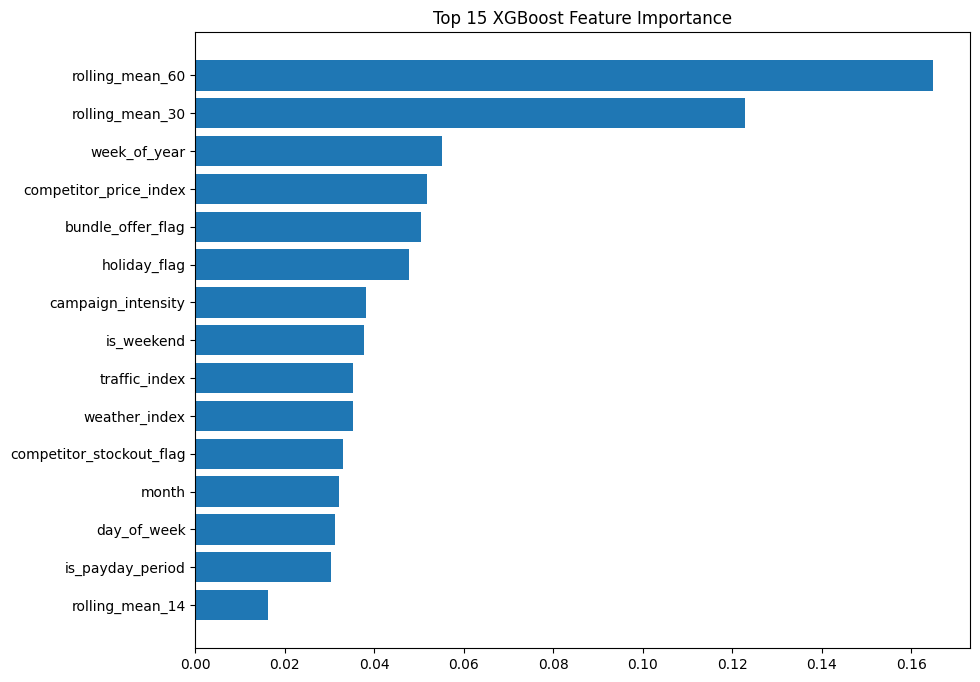

In [45]:
plt.figure(figsize=(10, 8))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 XGBoost Feature Importance")

plt.show()

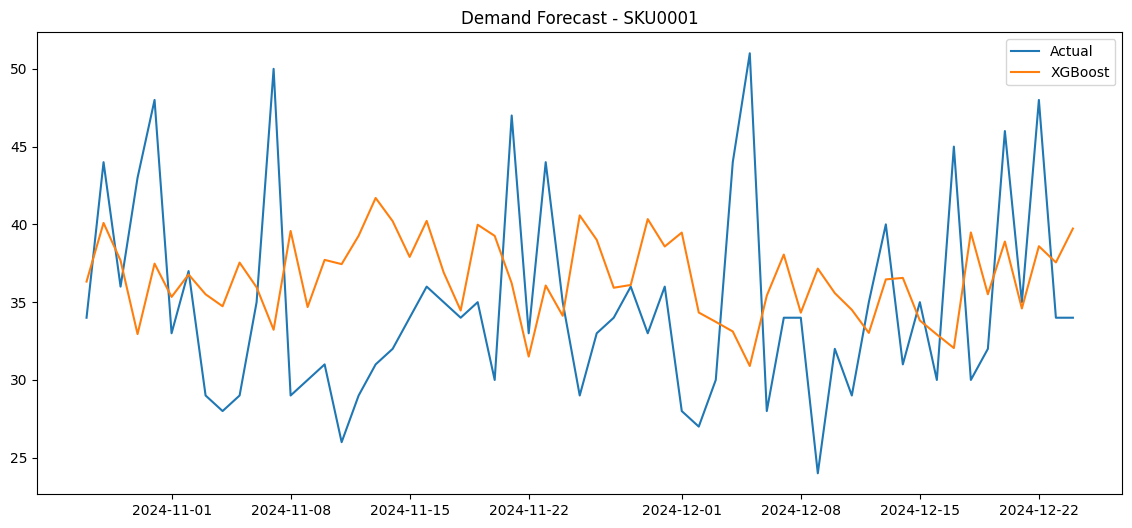

In [46]:
results = test.copy()

results["Prediction"] = xgb_pred

sample_sku = results["sku_id"].iloc[0]

plot_df = results[
    results["sku_id"] == sample_sku
]

plt.figure(figsize=(14,6))

plt.plot(
    plot_df["date"],
    plot_df["target_7d"],
    label="Actual"
)

plt.plot(
    plot_df["date"],
    plot_df["Prediction"],
    label="XGBoost"
)

plt.title(f"Demand Forecast - {sample_sku}")

plt.legend()

plt.show()

In [47]:
sales["predicted_demand"] = xgb.predict(X)

NameError: name 'X' is not defined